1️⃣ Install Dependencies

In [ ]:
!pip install transformers diffusers accelerate torch torchvision --quiet

!pip install streamlit diffusers transformers accelerate torch torchvision --quiet



2️⃣ Import Libraries


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from diffusers import StableDiffusionPipeline
from PIL import Image


3️⃣ Load AI Story Generator Model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-2")
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    torch_dtype=torch.float16,
    device_map="auto"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

4️⃣ Function: Generate Creative Story

In [ ]:
def generate_story(prompt):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")
    output = model.generate(
        input_ids,
        max_length=150,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
    )
    story = tokenizer.decode(output[0], skip_special_tokens=True)
    return story


5️⃣ Load Stable Diffusion Model


In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


6️⃣ Function: Generate Image from Story

In [ ]:
def generate_image(prompt):
    image = pipe(prompt).images[0]
    return image


7️⃣ Full App: Input → Story → Image

Enter a story theme: my faviorte flower  white rose


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



📝 Generated Story:
 Write a short imaginative story based on this theme: my faviorte flower  white rose. Story should be 4-6 lines.
## INPUT
my faviorte flower  white rose.
##OUTPUT
She loved the white rose, its fragrance and its beauty. She picked it every morning, and kept it in a vase on her windowsill. She wished she could tell him how much he meant to her, with every petal and every scent. But she knew he was gone, and that she would never see him again.


🎨 Generating Image...


  0%|          | 0/50 [00:00<?, ?it/s]

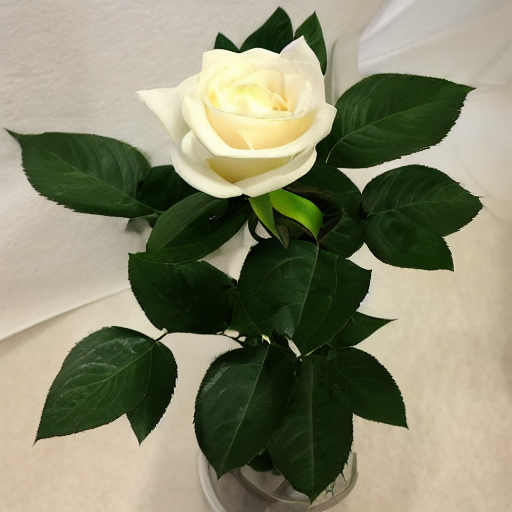

In [ ]:
user_theme = input("Enter a story theme: ")

story_prompt = f"Write a short imaginative story based on this theme: {user_theme}. Story should be 4-6 lines."

story = generate_story(story_prompt)
print("\n📝 Generated Story:\n", story)

print("\n🎨 Generating Image...")
image = generate_image(user_theme)
display(image)


Gradio ui

In [ ]:
!pip install diffusers transformers accelerate torch torchvision --quiet


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from diffusers import StableDiffusionPipeline
import gradio as gr


✅ 3️⃣ Load Story Generator Model (Phi-2)

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,       # fast + GPU friendly
    safety_checker=None              # optional: remove NSFW filter for creative tasks
).to("cuda")                         # send to GPU

pipe.enable_attention_slicing()      # reduces VRAM usage


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✅ 4️⃣ Load Stable Diffusion Model

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ 5️⃣ Story + Image Functions

In [ ]:
def generate_story(prompt):
    story_prompt = (
        f"Write a short imaginative story (4-6 lines) based on this theme: {prompt}. "
        "Make it creative, emotional, and engaging."
    )
    input_ids = tokenizer(story_prompt, return_tensors="pt").input_ids.to("cuda")

    output = model.generate(
        input_ids,
        max_length=180,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
    )

    story = tokenizer.decode(output[0], skip_special_tokens=True)
    return story


def generate_art(user_theme):
    story = generate_story(user_theme)
    image = pipe(user_theme).images[0]
    return story, image


✅ 6️⃣ Gradio UI

In [ ]:
ui = gr.Interface(
    fn=generate_art,
    inputs=gr.Textbox(label="Enter a Story Theme"),
    outputs=[
        gr.Textbox(label="Generated Story"),
        gr.Image(label="AI Generated Image")
    ],
    title="AI Story + Image Generator",
    description="Enter any theme. The AI will create a story and matching artwork.",
)

ui.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a37fc9c9820c9b26d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
%%writefile app.py
import streamlit as st
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from diffusers import StableDiffusionPipeline
from PIL import Image

# -------------------------------
# Load Story Model
# -------------------------------
@st.cache_resource
def load_story_model():
    tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-2")
    model = AutoModelForCausalLM.from_pretrained(
        "microsoft/phi-2",
        torch_dtype=torch.float16,
        device_map="auto"
    )
    return tokenizer, model

# -------------------------------
# Load Stable Diffusion Model
# -------------------------------
@st.cache_resource
def load_sd_model():
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    )
    return pipe.to("cuda")

tokenizer, model = load_story_model()
pipe = load_sd_model()

# -------------------------------
# Story Generator Function
# -------------------------------
def generate_story(prompt):
    full_prompt = f"Write a short creative story (4–6 lines) about: {prompt}."
    input_ids = tokenizer(full_prompt, return_tensors="pt").input_ids.to("cuda")

    output = model.generate(
        input_ids,
        max_length=180,
        temperature=0.8,
        top_p=0.9,
        do_sample=True
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# -------------------------------
# Streamlit UI
# -------------------------------
st.title("✨ AI Story + Image Generator (Streamlit)")
st.write("Enter any theme and AI will generate a story + artwork!")

theme = st.text_input("Enter story theme:", "")

if st.button("Generate"):
    if theme.strip() == "":
        st.warning("Please enter a theme!")
    else:
        with st.spinner("Generating story..."):
            story = generate_story(theme)

        with st.spinner("Generating image..."):
            image = pipe(theme).images[0]

        st.subheader("📝 Generated Story")
        st.write(story)

        st.subheader("🎨 AI Generated Image")
        st.image(image, caption="Generated by Stable Diffusion", use_column_width=True)
